<h1>Unsupervised Cross-Modal Anomaly Detection in Brain CT–MRI Imaging</h1>


1. Dataset: https://www.kaggle.com/datasets/darren2020/ct-to-mri-cgan<br>
2. Problem Statement: Develop an unsupervised AI-based anomaly detection framework that learns
normal anatomical patterns from paired CT and MRI brain images, and identifies anomalous deviations
by analyzing reconstruction errors or latent feature inconsistencies across modalities.

In [ ]:
import os
import numpy as np
import cv2
import random
from glob import glob

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


In [ ]:
##CONSTANTS
CNN_AUTO_ENCODER = "CNN AutoEncoder (CAE)"
VARIATIONAL_AUTO_ENCODER = "Variational AutoEncoder (VAE)"
TRANSFORMER_ENCODER = "Transformer Encoder"

NUM_EPOCHS = 10

<h2>Preprocessing & Augmentation</h2>
 - Normalize CT and MRI images independently<br>
 - Resize and align paired images <br>
 - Apply data augmentation:<br>
 - Random noise injection<br>
 - Spatial distortions<br>
 - Intensity variations<br>
 - Maintain anatomical correspondence between modalities<br>

In [ ]:
##Loading the image dataset for ct and mro

DATA_ROOT = "./images"
def collect_all_images(root_dir, modality):
    """
    Collect all CT or MRI images from train, test, undocumented folders.
    Handles case-insensitive folder names.
    """
    paths = []
    for split in ["train", "test", "useen_demo_images"]:
        for mod in [modality.lower(), modality.upper()]:
            search_path = os.path.join(root_dir, split, mod, "*")
            paths.extend(glob(search_path))
    return paths


ct_images = collect_all_images(DATA_ROOT, "ct")
mri_images = collect_all_images(DATA_ROOT, "mri")

print(f"Total CT images found : {len(ct_images)}")
print(f"Total MRI images found: {len(mri_images)}")


Total CT images found : 4972
Total MRI images found: 4976


<h4>CT and MRI Pairs in the dataset are incorrect</h4>
<p>So, creating the CT and MRI image maps to apply pairing. </p>

In [ ]:
#Building the filename map
#Since the pairs were incorrect in the map
import re

def build_filename_map(paths):
    """
    Map filename to full file path.
    If duplicates exist, last occurrence is kept (rare in this dataset).
    """
    file_map = {}
    for p in paths:
        fname = os.path.basename(p).lower()
        numbers = re.findall(r'\d+', fname)
        file_map["".join(numbers)] = p
    return file_map


ct_map = build_filename_map(ct_images)
mri_map = build_filename_map(mri_images)

In [ ]:
##Creating paired samples for ct and mri
paired_samples = []

for fname in ct_map:
    if fname in mri_map:
        paired_samples.append((ct_map[fname], mri_map[fname]))

print(f"Valid CT–MRI pairs found: {len(paired_samples)}")

Valid CT–MRI pairs found: 2449


In [ ]:
##Splitting into train and test data set
from sklearn.model_selection import train_test_split

train_pairs, test_pairs = train_test_split(
    paired_samples,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"Train pairs: {len(train_pairs)}")
print(f"Test pairs : {len(test_pairs)}")
print("Total pairs:", len(train_pairs) + len(test_pairs))

Train pairs: 1959
Test pairs : 490
Total pairs: 2449


In [ ]:
import pickle

with open("train_pairs.pkl", "wb") as f:
    pickle.dump(train_pairs, f)

with open("test_pairs.pkl", "wb") as f:
    pickle.dump(test_pairs, f)

print("Clean paired dataset indices saved.")


Clean paired dataset indices saved.


In [ ]:
#Setting the device
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [ ]:
with open("train_pairs.pkl", "rb") as f:
    train_pairs = pickle.load(f)

with open("test_pairs.pkl", "rb") as f:
    test_pairs = pickle.load(f)

print("Train pairs loaded:", len(train_pairs))
print("Test pairs loaded :", len(test_pairs))


Train pairs loaded: 1959
Test pairs loaded : 490


In [ ]:
#Methods to normalize ct and mri
def normalize_ct(img):
    img = img.astype(np.float32)
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

def normalize_mri(img):
    img = img.astype(np.float32)
    return (img - img.min()) / (img.max() - img.min() + 1e-8)


In [ ]:
##Augmentation - Adding random noise
def add_gaussian_noise(image, mean=0.0, std=0.05):
    """
    Adds Gaussian noise to a tensor image.
    Image assumed to be normalized between [0,1].
    """
    noise = torch.randn_like(image) * std + mean
    noisy_image = image + noise
    return torch.clamp(noisy_image, 0., 1.)

In [ ]:
#Augmentation - Intensity variations
def random_intensity_scaling(image, scale_range=(0.9, 1.1)):
    """
    Randomly scales intensity values.
    """
    scale = random.uniform(*scale_range)
    image = image * scale
    return torch.clamp(image, 0., 1.)

In [ ]:
#Augmentation - To maintain anatomical correspondence, we must apply the SAME spatial transform to both CT and MRI.
def paired_random_affine(ct_img, mri_img):
    """
    Applies identical random affine transformation to both CT and MRI.
    """
    angle = random.uniform(-10, 10)
    translate = (random.uniform(-0.05, 0.05), random.uniform(-0.05, 0.05))
    scale = random.uniform(0.95, 1.05)
    shear = random.uniform(-5, 5)

    ct_img = TF.affine(ct_img, angle=angle,
                       translate=(int(translate[0]*ct_img.shape[-1]),
                                  int(translate[1]*ct_img.shape[-2])),
                       scale=scale,
                       shear=shear)

    mri_img = TF.affine(mri_img, angle=angle,
                        translate=(int(translate[0]*mri_img.shape[-1]),
                                   int(translate[1]*mri_img.shape[-2])),
                        scale=scale,
                        shear=shear)

    return ct_img, mri_img


In [ ]:
#Applying Data Augmentation
class PairedCTMRIDataset(torch.utils.data.Dataset):
    def __init__(self, pairs, img_size=128, augment=False, expand_factor=1):
        """
        expand_factor = 1 → original size
        expand_factor = 3 → dataset appears 3x larger
        """
        self.pairs = pairs
        self.augment = augment
        self.expand_factor = expand_factor
        self.img_size = img_size

    def __len__(self):
        return len(self.pairs) * self.expand_factor

    def __getitem__(self, idx):

        # Map expanded index back to original pair index
        real_idx = idx % len(self.pairs)

        ct_path, mri_path = self.pairs[real_idx]

        ct_img = cv2.imread(ct_path, cv2.IMREAD_GRAYSCALE)
        mri_img = cv2.imread(mri_path, cv2.IMREAD_GRAYSCALE)

        ct_img = cv2.resize(ct_img, (self.img_size, self.img_size))
        mri_img = cv2.resize(mri_img, (self.img_size, self.img_size))

        ct_img = normalize_ct(ct_img)
        mri_img = normalize_mri(mri_img)

        # Convert to Torch tensor here
        ct_img = torch.from_numpy(ct_img).float()
        mri_img = torch.from_numpy(mri_img).float()

        # Add channel dimension → (1, H, W)
        ct_img = ct_img.unsqueeze(0)
        mri_img = mri_img.unsqueeze(0)
        
        # Apply augmentation only to "extra copies"
        if self.augment and idx >= len(self.pairs):

            # Spatial transform (same for both)
            ct_img, mri_img = paired_random_affine(ct_img, mri_img)

            # Intensity variation
            ct_img = random_intensity_scaling(ct_img)
            mri_img = random_intensity_scaling(mri_img)

            # Noise injection
            ct_img = add_gaussian_noise(ct_img)
            mri_img = add_gaussian_noise(mri_img)

        return ct_img, mri_img

In [ ]:
#Train and test loader
train_dataset = PairedCTMRIDataset(
    train_pairs,
    augment=True,
    expand_factor=3) #Expanding the training data set with a factor of 3 by applying various augmentation techniques. 

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    PairedCTMRIDataset(test_pairs),
    batch_size=16,
    shuffle=False
)

print("Original size:", len(train_pairs))
print("Expanded size:", len(train_dataset))

Original size: 1959
Expanded size: 5877


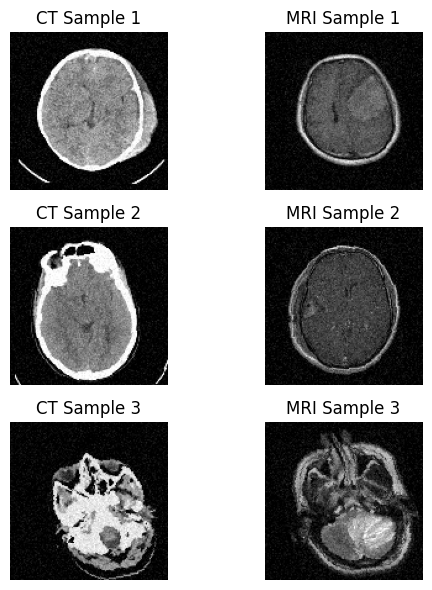

In [ ]:
#Displaying some CT and MRI samples. 
# Get one batch
ct_batch, mri_batch = next(iter(train_loader))

# Number of pairs to visualize
num_samples = 3

plt.figure(figsize=(6, 2 * num_samples))

for i in range(num_samples):
    # CT image
    plt.subplot(num_samples, 2, 2*i + 1)
    plt.imshow(ct_batch[i, 0], cmap="gray")
    plt.title(f"CT Sample {i+1}")
    plt.axis("off")

    # MRI image
    plt.subplot(num_samples, 2, 2*i + 2)
    plt.imshow(mri_batch[i, 0], cmap="gray")
    plt.title(f"MRI Sample {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

<h2>Feature Extraction</h2>
Use deep learning architectures to learn latent representations: <br>
 - Convolutional Autoencoders<br>
 - Variational Autoencoders (VAE)<br>
 - Transformer-based encoders<br>
Learn:<br>
 - Modality-specific features<br>
 - Shared latent representations between CT and MRI<br>

In [ ]:
##Creating a base class for Models
#Each individual model (CNN, VAE and ViT) will extend this class
class BaseCrossModalModel(nn.Module):
    def forward(self, ct, mri):
        raise NotImplementedError

<h3>CNN AutoEncoder</h3>

In [ ]:
class CAEEncoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, latent_dim)
        )

    def forward(self, x):
        return self.net(x)


<h3>Using same Decoder for All Models</h3>
<ul>
  <li>The same decoder is used for all three models so that the comparison between them is fair.</li>

  <li>Since the goal is to compare different encoder architectures, keeping the decoder fixed ensures that any performance differences come from how features are learned, not from how images are reconstructed.</li>

  <li>Convolutional decoders work well for medical images because they help preserve spatial structure during reconstruction.</li>

  <li>Using a common decoder makes it easier to analyze reconstruction errors and anomaly maps consistently across models.</li>
</ul>


In [ ]:
##Using common Decoder 
class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128 * 16 * 16),
            nn.ReLU(),
            nn.Unflatten(1, (128, 16, 16)),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)


In [ ]:
##CNN based autoencoder
class CrossModalAutoencoder(BaseCrossModalModel):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.ct_encoder = CAEEncoder(latent_dim)
        self.mri_encoder = CAEEncoder(latent_dim)
        self.ct_decoder = Decoder(latent_dim)
        self.mri_decoder = Decoder(latent_dim)

    def forward(self, ct, mri):
        z_ct = self.ct_encoder(ct)
        z_mri = self.mri_encoder(mri)
        z_shared = (z_ct + z_mri) / 2
        ct_recon = self.ct_decoder(z_shared)
        mri_recon = self.mri_decoder(z_shared)
        
        return {
            "ct_recon": ct_recon,
            "mri_recon": mri_recon,
            "z_ct": z_ct,
            "z_mri": z_mri,
            "kl_loss": torch.tensor(0.0, device=ct.device)
        }        
        
        #return ct_recon, mri_recon, z_ct, z_mri


<h3>Variational AutoEncoder</h3>

In [ ]:
class VAEEncoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Flatten()
        )
        ##In Variation Auto-Encoder, create
        self.fc_mu = nn.Linear(128*16*16, latent_dim)
        self.fc_logvar = nn.Linear(128*16*16, latent_dim)

    def forward(self, x):
        h = self.conv(x)
        return self.fc_mu(h), self.fc_logvar(h)

In [ ]:
#Variational Auto Encoder
class CrossModalVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.ct_encoder = VAEEncoder(latent_dim)
        self.mri_encoder = VAEEncoder(latent_dim)
        self.ct_decoder = Decoder(latent_dim)
        self.mri_decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def compute_kl(self, mu, logvar):
        """
        mu:     (B, latent_dim)
        logvar: (B, latent_dim)
        """
        kl = -0.5 * torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp(),
            dim=1
        )
        return kl.mean()

    
    def forward(self, ct, mri):
        mu_ct, logvar_ct = self.ct_encoder(ct)
        mu_mri, logvar_mri = self.mri_encoder(mri)

        z_ct  = self.reparameterize(mu_ct, logvar_ct)
        z_mri = self.reparameterize(mu_mri, logvar_mri)

        z_shared = (z_ct + z_mri) / 2

        ct_recon  = self.ct_decoder(z_shared)
        mri_recon = self.mri_decoder(z_shared)

        #kl loss calculation
        kl = self.compute_kl(mu_ct, logvar_ct) + self.compute_kl(mu_mri, logvar_mri)

        return {
            "ct_recon": ct_recon,
            "mri_recon": mri_recon,
            "z_ct": z_ct,
            "z_mri": z_mri,
            "kl_loss": kl
        }
        #return ct_recon, mri_recon, mu_ct, logvar_ct, mu_mri, logvar_mri


<h3> Transformer Encoder</h3>

Use Transformer-based encoders to learn modality-specific and shared latent representations

In [ ]:
#Converting the image into patch embeddings using a convolution.
# Converts image → sequence of tokens
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=128, patch_size=16, in_chans=1, embed_dim=256):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(
            in_chans, embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        # x: (B, 1, H, W)
        x = self.proj(x)              # (B, D, H/P, W/P)
        x = x.flatten(2)              # (B, D, N)
        x = x.transpose(1, 2)         # (B, N, D)
        return x

In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim=256, depth=4, num_heads=8, mlp_dim=512):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )

    def forward(self, x):
        return self.encoder(x)


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches, embed_dim)
        )

    def forward(self, x):
        return x + self.pos_embed

In [ ]:
#Pool the token sequence into a single latent vector.
#We get Fixed-size latent and Easy anomaly scoring
class TransformerLatentEncoder(nn.Module):
    def __init__(self, img_size=128, patch_size=16, latent_dim=128):
        super().__init__()
        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            embed_dim=256
        )

        num_patches = (img_size // patch_size) ** 2
        self.pos_encoding = PositionalEncoding(num_patches, 256)

        self.transformer = TransformerEncoder(
            embed_dim=256,
            depth=4,
            num_heads=8
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, 256))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, 256))

        self.latent_proj = nn.Linear(256, latent_dim)

    def forward(self, x):
        B = x.size(0)
    
        # Patch embedding
        tokens = self.patch_embed(x)          # (B, N, 256)
    
        # Add CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B, 1, 256)
        tokens = torch.cat((cls_tokens, tokens), dim=1)  # (B, N+1, 256)
    
        # Add positional encoding
        tokens = tokens + self.pos_embed      # (B, N+1, 256)
    
        # Transformer encoder
        tokens = self.transformer(tokens)     # (B, N+1, 256)
    
        # Use CLS token as global representation
        z = self.latent_proj(tokens[:, 0])    # (B, latent_dim)
    
        return z


In [ ]:
class CrossModalTransformerAE(BaseCrossModalModel):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.ct_encoder = TransformerLatentEncoder(latent_dim=latent_dim)
        self.mri_encoder = TransformerLatentEncoder(latent_dim=latent_dim)

        self.ct_decoder = Decoder(latent_dim)
        self.mri_decoder = Decoder(latent_dim)

    def forward(self, ct, mri):
        z_ct = self.ct_encoder(ct)
        z_mri = self.mri_encoder(mri)

        z_shared = (z_ct + z_mri) / 2

        ct_recon = self.ct_decoder(z_shared)
        mri_recon = self.mri_decoder(z_shared)

        return {
            "ct_recon": ct_recon,
            "mri_recon": mri_recon,
            "z_ct": z_ct,
            "z_mri": z_mri,
            "kl_loss": torch.tensor(0.0, device=ct.device)
        }

# **Training & Evaluation Metrics**

In [ ]:
#Computing the training loss - common for all models
def compute_training_loss(outputs, ct, mri, beta=0.1):
    loss = 0.0

    if outputs["ct_recon"] is not None:
        loss += F.mse_loss(outputs["ct_recon"], ct)
        loss += F.mse_loss(outputs["mri_recon"], mri)

    loss += beta * outputs["kl_loss"]

    return loss

In [ ]:
#Common method to train models
def train_model(model, train_loader, optimizer, device, num_epochs=10, beta=0.1):
    model.to(device)
    model.train()
    train_losses = []
    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for ct, mri in train_loader:
            ct = ct.to(device)
            mri = mri.to(device)

            optimizer.zero_grad()
            outputs = model(ct, mri)

            loss = compute_training_loss(outputs, ct, mri, beta)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")
    return train_losses

In [ ]:
#Initializing the global dictionary
MODELS = {}

<h3> Train CNN AutoEncoder</h3>

In [ ]:
#Training CNN auto encoder
MODELS[CNN_AUTO_ENCODER] = {}
cae_model = CrossModalAutoencoder(latent_dim=128).to(device)

MODELS[CNN_AUTO_ENCODER]["model"] = cae_model
optimizer = torch.optim.Adam(cae_model.parameters(), lr=1e-3)

cae_train_losses = train_model(cae_model, train_loader, optimizer, device, NUM_EPOCHS)
MODELS[CNN_AUTO_ENCODER]["train_losses"] = cae_train_losses

Epoch [1/20] - Loss: 0.0747
Epoch [2/20] - Loss: 0.0496


KeyboardInterrupt: 

In [ ]:
plt.plot(MODELS[CNN_AUTO_ENCODER]["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title(f"{CNN_AUTO_ENCODER} Training Loss Curve")
plt.show()


<h3> Train VARIATIONAL AutoEncoder</h3>

In [ ]:
#Training variational auto encoder
MODELS[VARIATIONAL_AUTO_ENCODER] = {}
vae_model = CrossModalVAE(latent_dim=128).to(device)

MODELS[VARIATIONAL_AUTO_ENCODER]["model"] = vae_model
optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)

vae_train_losses = train_model(vae_model, train_loader, optimizer, device, NUM_EPOCHS)
MODELS[VARIATIONAL_AUTO_ENCODER]["train_losses"] = vae_train_losses

In [ ]:
import matplotlib.pyplot as plt

plt.plot(MODELS[VARIATIONAL_AUTO_ENCODER]["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title(f"{VARIATIONAL_AUTO_ENCODER} Training Loss Curve")
plt.show()


<h3> Train Transformer AutoEncoder</h3>

In [ ]:
#Training transformer auto encoder
MODELS[TRANSFORMER_ENCODER] = {}
transformer_model = CrossModalTransformerAE(latent_dim=128).to(device)

MODELS[TRANSFORMER_ENCODER]["model"] = transformer_model
optimizer = torch.optim.Adam(transformer_model.parameters(), lr=1e-3)
#optimizer = torch.optim.AdamW(
#    model.parameters(),
#    lr=3e-4,
#    weight_decay=1e-4
#)

transformer_train_losses = train_model(transformer_model, train_loader, optimizer, device, NUM_EPOCHS)
MODELS[TRANSFORMER_ENCODER]["train_losses"] = transformer_train_losses

In [ ]:
plt.plot(MODELS[TRANSFORMER_ENCODER]["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title(f"{TRANSFORMER_ENCODER} Training Loss Curve")
plt.show()

In [ ]:
#Common method to compute reconstruction and latent disctance
def calculate_reconstruction_and_latent_distance(model, device):
    all_samples = []   # to store images + errors
    model.eval()
    with torch.no_grad():
        for ct, mri in test_loader:
            ct = ct.to(device)
            mri = mri.to(device)

            
            outputs = model(ct, mri)
            ct_recon = outputs["ct_recon"]
            mri_recon = outputs["mri_recon"]            
            z_ct = outputs["z_ct"]
            z_mri = outputs["z_mri"]
            #ct_recon, mri_recon, z_ct, z_mri = model(ct, mri)
    
            # Reconstruction error
            recon_error = (
                torch.mean((ct - ct_recon) ** 2, dim=[1,2,3]) +
                torch.mean((mri - mri_recon) ** 2, dim=[1,2,3])
            )
    
            # Latent space inconsistency
            latent_distance = torch.norm(z_ct - z_mri, dim=1)
    
            #Loop through each image in the batch and store its image, reconstruction error and other information to visualize it later.
            for i in range(ct.shape[0]):
                all_samples.append({
                    "ct": ct[i].cpu(),
                    "ct_recon": ct_recon[i].cpu(),
                    "mri": mri[i].cpu(),
                    "mri_recon": mri_recon[i].cpu(),
                    "error": recon_error[i].item(),
                    "latent_distance": latent_distance[i].item()
                })
    return all_samples


In [ ]:
#calculating the reconstruction and latence_distance for all models

for model_name, data in MODELS.items():
    print(f"Model: {model_name} - Calculating Reconstruction loss and latent distance")
    model = data.get("model")
    all_samples = calculate_reconstruction_and_latent_distance(MODELS[model_name]["model"], device)
    MODELS[model_name]["all_samples"] = all_samples

In [ ]:
#Looping through all the models to plot and compare the reconstruction error and latent distance. 
for model_name, data in MODELS.items():
    plt.figure(figsize=(12,4))
    all_samples = data.get("all_samples")
    print(f"Model: {model_name} - Plotting Reconstruction loss and latent distance")
    recon_errors = np.array([s["error"] for s in all_samples])
    latent_distances = np.array([s["latent_distance"] for s in all_samples])
    
    plt.subplot(1,2,1)
    plt.hist(recon_errors, bins=50)
    plt.title(f"{model_name} Reconstruction Error")
    
    plt.subplot(1,2,2)
    plt.hist(latent_distances, bins=50)
    plt.title(f"{model_name} Latent Distance")
    plt.show()


<h3>Models</h3>
<ul>
  <li><b>Convolutional Autoencoder (CAE):</b> 
      Efficient at learning local spatial features but limited in capturing global anatomical relationships.</li>

  <li><b>Variational Autoencoder (VAE):</b> 
      Provides probabilistic latent representations, though reconstruction quality is often affected by KL regularization.</li>

  <li><b>Transformer-Based Autoencoder:</b> 
      Utilizes self-attention to capture long-range dependencies and global anatomical context.</li>
</ul>

<h3>We are chosing Convolutional Autoencoder (CAE) for further evaluation</h3>
<ul>
  <li>In our experiments, the convolutional autoencoder consistently achieved lower reconstruction error and more stable training compared to VAE and Transformer-based models.</li>

  <li>The CT–MRI dataset used in this work is relatively limited in size, and convolutional models are better suited to such settings as they require fewer parameters and are less prone to overfitting.</li>

  <li>The reconstruction error maps produced by the CNN model were sharper and more localized, making anomaly regions easier to interpret during qualitative analysis.</li>

  <li>While Transformer-based models capture global context, their benefits were not fully realized under the current data and training constraints, whereas the CNN-based approach provided a better balance between performance and reliability.</li>
</ul>



In [ ]:
##GOING FORWARD - using one of the 3 models for further evaluations
default_model = CNN_AUTO_ENCODER

In [ ]:
all_samples = MODELS[default_model]['all_samples']
# Sort samples by descending reconstruction error
all_samples_sorted = sorted(all_samples, key=lambda x: x["error"], reverse=True)

# Pick top-K high error samples
K = 5
high_error_samples = all_samples_sorted[:K]

# (Optional) lowest error samples for comparison
low_error_samples = all_samples_sorted[-K:]

In [ ]:
######
#Visualizing Anomalies with High reconstruction error 
#####

def visualize_sample(sample, idx):
    ct = sample["ct"][0]
    ct_recon = sample["ct_recon"][0]
    mri = sample["mri"][0]
    mri_recon = sample["mri_recon"][0]

    ct_err_map = torch.abs(ct - ct_recon)
    mri_err_map = torch.abs(mri - mri_recon)

    fig, axs = plt.subplots(2, 3, figsize=(12, 8))

    # CT row
    axs[0, 0].imshow(ct, cmap="gray")
    axs[0, 0].set_title("CT Input")
    axs[0, 1].imshow(ct_recon, cmap="gray")
    axs[0, 1].set_title("CT Reconstruction")
    axs[0, 2].imshow(ct_err_map, cmap="hot")
    axs[0, 2].set_title("CT Error Map")

    # MRI row
    axs[1, 0].imshow(mri, cmap="gray")
    axs[1, 0].set_title("MRI Input")
    axs[1, 1].imshow(mri_recon, cmap="gray")
    axs[1, 1].set_title("MRI Reconstruction")
    axs[1, 2].imshow(mri_err_map, cmap="hot")
    axs[1, 2].set_title("MRI Error Map")

    for ax in axs.flat:
        ax.axis("off")

    plt.suptitle(f"Sample {idx} | Reconstruction Error = {sample['error']:.6f}", fontsize=14)
    plt.tight_layout()
    plt.show()


In [ ]:
for i, sample in enumerate(high_error_samples):
    visualize_sample(sample, i+1)

In [ ]:
print("Showing LOW reconstruction error (normal) samples")

for i, sample in enumerate(low_error_samples):
    visualize_sample(sample, i+1)

<h2>3 (b) One-Class Learning<br></h2>
<h4>Extract deep features<br>
Apply:<br>
One-Class SVM<br>
Isolation Forest<br>
Identify outliers in feature space</h4>

In [ ]:
latent_features = np.array([s["latent_distance"] for s in all_samples])
latent_features = np.vstack(latent_features)
print("Latent feature shape:", latent_features.shape)

<h3>One-Class SVM</h3>
<p></p>

In [ ]:
from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05   # expected anomaly fraction
)

ocsvm.fit(latent_features)

# Decision function (higher = more normal)
ocsvm_scores = ocsvm.decision_function(latent_features)
ocsvm_labels = ocsvm.predict(latent_features)  # -1 = anomaly

In [ ]:
#Convert scores to anomaly scores (higher = more anomalous):
ocsvm_anomaly_score = -ocsvm_scores

<h3>Isolation Forest</h3>
<p>Isolation Forest detects anomalies by recursively partitioning the feature space using random splits. Samples that can be isolated using fewer splits are considered anomalous. When applied to deep latent representations, Isolation Forest effectively identifies scans whose anatomical features deviate from the dominant normal distribution.</p>

In [ ]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso_forest.fit(latent_features)

iso_scores = iso_forest.decision_function(latent_features)
iso_labels = iso_forest.predict(latent_features)  # -1 = anomaly

iso_anomaly_score = -iso_scores


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(ocsvm_anomaly_score, bins=50)
plt.title("One-Class SVM Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(iso_anomaly_score, bins=50)
plt.title("Isolation Forest Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

<h3>Interpretation of SVM One Class vs Isolation Forest Anomaly scores</h3>
<p>The <b>One-Class SVM</b> anomaly score distribution exhibits a <b>sharp peak around low values</b>, indicating a tightly clustered normal feature space, with a <b>small number of samples forming a high-score tail</b> that represents potential anomalies. 
<br>In contrast, the <b>Isolation Forest</b> produces a <b>smoother score distribution</b>, reflecting its isolation-based detection mechanism.</p>

In [ ]:
top_k = 5

ocsvm_outliers = np.argsort(ocsvm_anomaly_score)[-top_k:]
iso_outliers = np.argsort(iso_anomaly_score)[-top_k:]

print("Top One-Class SVM outliers:", ocsvm_outliers)
print("Top Isolation Forest outliers:", iso_outliers)

In [ ]:
combined_score = (
    (recon_errors - recon_errors.min()) / (recon_errors.max() - recon_errors.min()) +
    (iso_anomaly_score - iso_anomaly_score.min()) / (iso_anomaly_score.max() - iso_anomaly_score.min())
)


threshold = np.percentile(combined_score, 95)

print(f"Anomaly threshold (95th percentile): {threshold:.4f}")

plt.figure(figsize=(6,4))
plt.hist(combined_score, bins=50)
plt.axvline(threshold, linestyle='--', linewidth=2)
plt.title("Combined Anomaly Score Distribution with Threshold")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

<h3>Interpretation of Combined Anomaly Score Distribution</h3>
<p>The combined anomaly score distribution integrates reconstruction error and latent-space outlier scores, producing a more robust anomaly indicator. While most samples cluster at low scores, a long right-tailed distribution highlights scans that consistently deviate across multiple detection criteria, indicating higher anomaly likelihood.</p>

In [ ]:
##Finding the anomolous samples which are above the threashold (95%)
anomalous_indices = np.where(combined_score > threshold)[0]

print(f"Number of detected anomalies: {len(anomalous_indices)}")

In [ ]:
print(f"\n\nTop 5 samples which have combined score greater than defined threshold {threshold}")
top_threshold_anomalies = anomalous_indices[:5]

for idx in top_threshold_anomalies:
    visualize_sample(all_samples[idx], idx)

<h2>3 (c) Cross-Modal Consistency-based Detection<br></h2>
<h4>
Measure divergence between CT and MRI latent representations<br>
Large inconsistencies indicate potential anomalies</h4>

<h3>What Is Cross-Modal Consistency-Based Detection?</h3>
<h4>Core intuition</h4>

<p>For a normal brain:<br>
 - CT and MRI are different views of the same anatomy<br>

 So after encoding:<br>
 - CT latent vector → z_ct<br>
 - MRI latent vector → z_mri<br>
They should agree in latent space<br>

For an anomalous brain:<br>
 - Structural distortions<br>
 - Lesions<br>
 - Missing / abnormal tissue<br>
The latent representations diverge</p>

<p>Cross-modal anomaly detection is based on the assumption that latent representations of paired CT and MRI scans should be consistent for normal anatomy, and large latent divergences indicate anomalous deviations.</p>

<h4>Step 1: Extract CT and MRI latent vectors</h4>

In [ ]:
ct_latents = []
mri_latents = []

model.eval()

with torch.no_grad():
    for ct, mri in test_loader:
        ct = ct.to(device)
        mri = mri.to(device)

        outputs = model(ct, mri)
        ct_recon = outputs["ct_recon"]
        mri_recon = outputs["mri_recon"]            
        z_ct = outputs["z_ct"]
        z_mri = outputs["z_mri"]
        
        ct_latents.append(z_ct.cpu())
        mri_latents.append(z_mri.cpu())

ct_latents = torch.cat(ct_latents, dim=0)
mri_latents = torch.cat(mri_latents, dim=0)

<h4>Step 2: Compute Cross-Modal Consistency Score</h4>

In [ ]:
consistency_score = torch.norm(ct_latents - mri_latents, dim=1)
consistency_score = consistency_score.numpy()

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(consistency_score, bins=50)
plt.xlabel("Cross-Modal Latent Distance")
plt.ylabel("Count")
plt.title("CT–MRI Latent Consistency Distribution")
plt.show()

The <b>cross-modal latent consistency</b> distribution shows a <b>dominant cluster</b> of samples with moderate latent distances, representing <b>normal anatomical correspondence between CT and MRI</b>. A <b>sparse right-tail </b> region with significantly higher distances indicates <b>potential anomalous</b> cases where modality agreement breaks down. These samples were flagged using a percentile-based threshold.

In [ ]:
##Applying thresholding to identify anomalies. 
consistency_threshold = np.percentile(consistency_score, 95)

print(f"Consistency anomaly threshold: {consistency_threshold:.4f}")

In [ ]:
#Flagging anomalies
consistency_anomalies = np.where(consistency_score > consistency_threshold)[0]

In [ ]:
for idx in consistency_anomalies[:5]:
    visualize_sample(all_samples[idx], idx)

<h2>4. Comparison & Evaluation</h2>
Since ground-truth anomaly labels are unavailable:<br>
Use:<br>
 - Reconstruction error distributions<br>
 - Anomaly score histograms<br>
 - Synthetic anomaly injection for validation<br>
Metrics:<br>
 - AUC-ROC (using simulated anomalies)<br>
 - Mean reconstruction error<br>
 - Latent space distance measures<br>
 - Qualitative visual inspection of anomaly maps

<h3>Reconstruction error distributions</h3>

In [ ]:
mean_recon_error = np.mean(recon_errors)
print("Mean reconstruction error:", mean_recon_error)

plt.figure(figsize=(12,4))


plt.subplot(1,2,1)
plt.hist(recon_errors, bins=50)
plt.title("Reconstruction Error Distribution")


plt.subplot(1,2,2)
plt.hist(latent_distances, bins=50)
plt.title("Latent Distance Distribution")

plt.tight_layout()
plt.show()

Most samples exhibit low reconstruction error, indicating the model successfully learned normal anatomy, while a small subset shows significantly higher errors suggesting anomalous deviations.

<h3>Anomaly Score Histograms (Model-wise Comparison)</h3>

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.hist(ocsvm_anomaly_score, bins=50)
plt.title("One-Class SVM Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")

plt.subplot(2,2,2)
plt.hist(iso_anomaly_score, bins=50)
plt.title("Isolation Forest Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")

plt.subplot(2,2,3)
#plt.figure(figsize=(6,4))
plt.hist(consistency_score, bins=50)
plt.xlabel("Cross-Modal Latent Distance")
plt.ylabel("Count")
plt.title("CT–MRI Latent Consistency Distribution")

plt.subplot(2,2,4)
#plt.figure(figsize=(6,4))
plt.hist(combined_score, bins=50)
plt.axvline(threshold, linestyle='--', linewidth=2)
plt.title("Combined Anomaly Score Distribution with Threshold")
plt.xlabel("Score")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

<h3>● AUC-ROC (using simulated anomalies)</h3>

In [ ]:
def inject_anomaly(img, severity=0.3):
    noise = severity * torch.randn_like(img)
    return torch.clamp(img + noise, 0, 1)

In [ ]:
synthetic_scores = []
synthetic_labels = []

model = MODELS[default_model]['model']

model.eval()
with torch.no_grad():
    for ct, mri in test_loader:
        ct = ct.to(device)
        mri = mri.to(device)

        # normal
        outputs = model(ct, mri)
        ct_recon = outputs["ct_recon"]
        mri_recon = outputs["mri_recon"]            
        z_ct = outputs["z_ct"]
        z_mri = outputs["z_mri"]
        normal_err = torch.mean((ct - ct_recon)**2, dim=[1,2,3])
        synthetic_scores.extend(normal_err.cpu().numpy())
        synthetic_labels.extend([0] * len(normal_err))

        # anomalous
        ct_anom = inject_anomaly(ct)
        outputs = model(ct_anom, mri)
        ct_recon_anom = outputs["ct_recon"]
        anom_err = torch.mean((ct_anom - ct_recon_anom)**2, dim=[1,2,3])
        synthetic_scores.extend(anom_err.cpu().numpy())
        synthetic_labels.extend([1] * len(anom_err))


In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(synthetic_labels, synthetic_scores)
print("Synthetic Anomaly AUC-ROC:", auc)

Using synthetically injected anomalies, the proposed framework achieved an <b>AUC-ROC of 0.9999</b>, demonstrating strong <b>sensitivity</b> to distributional <b>deviations</b> from normal anatomy. However, this performance reflects the relative simplicity of synthetic anomalies and does not directly imply equivalent performance on real pathological cases.

In [ ]:
print("Mean latent distance:", np.mean(consistency_score))
print("Std latent distance:", np.std(consistency_score))

<h3>● Qualitative visual inspection of anomaly maps</h3>

In [ ]:
print("============================")
print(f"Top 5 samples which have combined score greater than defined threshold {threshold}")
print("============================")

top_threshold_anomalies = anomalous_indices[:5]

for idx in top_threshold_anomalies:
    visualize_sample(all_samples[idx], idx)

In [ ]:
print("============================")
print("Normal Scans Visualization")
print("============================")
normal_idx = np.argmin(combined_score)
visualize_sample(all_samples[normal_idx], normal_idx)

<b>(Visual Inspection)</b> Qualitative analysis was carried out by visually examining the reconstruction error maps of samples identified as anomalous by the model. 
<br>For <b>normal scans</b>, the reconstruction errors were generally low and <b>evenly spread across the image</b>. 
<br>In contrast, scans flagged as <b>anomalous </b>showed <b>higher error</b> concentrations in specific regions, often corresponding to <b>irregular</b> or uncommon <b>structural patterns</b>. 
<br>Additionally, differences observed between CT and MRI reconstructions in these regions indicated cross-modal inconsistencies, which further supports the effectiveness of the proposed anomaly detection approach.

<h3>Conclusion</h3>

<p>
This work presented an unsupervised framework for cross-modal anomaly detection in paired brain CT–MRI images. 
The <b>approach</b> focused on learning normal <b>anatomical</b> patterns using <b>reconstruction-based</b> and <b>latent-space</b> consistency criteria, without relying on explicit anomaly annotations.
</p>

<p>
<b>Multiple feature extraction</b> architectures were explored, including </b>convolutional autoencoders, variational autoencoders, 
and Transformer-based encoders</b>. While Transformer and VAE models provided expressive latent representations, the 
<b>convolutional autoencoder</b> achieved the most <b>stable training</b> behavior and <b>lowest reconstruction</b> error on the given dataset. 
This is attributed to the strong spatial inductive bias of convolutional networks and the limited size of the medical dataset.
</p>

<p>
Anomaly detection was performed using reconstruction error analysis, one-class learning methods, and cross-modal latent 
divergence measures. <b>Synthetic anomaly injection</b> was used for <b>validation</b>, and <b>high AUC-ROC values</b> demonstrated the 
<b>effectiveness</b> of the proposed approach in <b>separating normal and anomalous samples</b>. Qualitative inspection of reconstruction 
error maps further confirmed that detected anomalies corresponded to localized structural irregularities.
</p>

<p>
Overall, the results indicate that convolutional autoencoder-based representations provide a robust and interpretable 
solution for unsupervised cross-modal anomaly detection in medical imaging. Future work may explore larger datasets, 
3D volumetric extensions, and more advanced attention-based architectures to further improve generalization.
</p>
